In [ ]:
# pip install tensorflow matplotlib scikit-learn

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Treinamento com Holdout:


/usr/local/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8072 - loss: 0.6039 - val_accuracy: 0.9787 - val_loss: 0.0724
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9659 - loss: 0.1183 - val_accuracy: 0.9858 - val_loss: 0.0496
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9747 - loss: 0.0837 - val_accuracy: 0.9874 - val_loss: 0.0431
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9804 - loss: 0.0645 - val_accuracy: 0.9889 - val_loss: 0.0398
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9830 - loss: 0.0570 - val_accuracy: 0.9901 - val_loss: 0.0362
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9845 - loss: 0.0522 - val_accuracy: 0.9905 - val_loss: 0.0332
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9862 - loss: 0.0435 - val_accuracy: 0.9908 - val_loss: 0.0333
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9874 - loss: 0.0388 - 

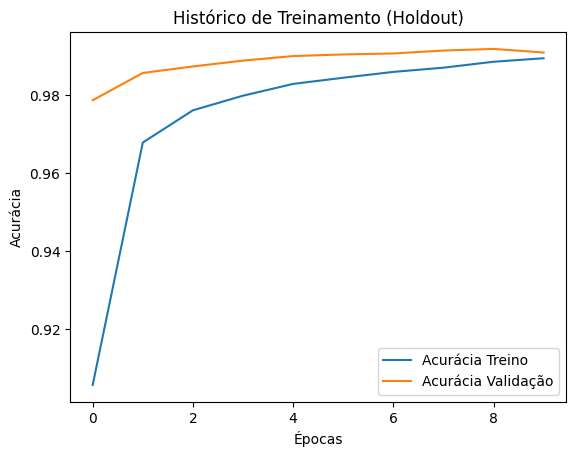

Validação Cruzada com k-fold:
Acurácia no Fold: 0.9884
Acurácia no Fold: 0.9891
Acurácia no Fold: 0.9883
Acurácia no Fold: 0.9881
Acurácia no Fold: 0.9887

Média de Acurácia (k-fold): 0.9885
Desvio Padrão (k-fold): 0.0003

Comparação Final:
Acurácia (Holdout): 0.9914
Média de Acurácia (k-fold): 0.9885
Desvio Padrão (k-fold): 0.0003


In [5]:
# Importação de Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Garantir reprodutibilidade
np.random.seed(42)

# Carregando a base de dados MNIST
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Pré-processamento
# Redimensionar e normalizar os dados
X_train_full = X_train_full.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0
y_train_full = to_categorical(y_train_full, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Divisão treino/validação para holdout
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Construção do Modelo CNN
def create_model():
    model = Sequential([
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Treinamento com Holdout
print("Treinamento com Holdout:")
model_holdout = create_model()
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model_holdout.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop])

# Avaliação com os dados de teste
loss, acc = model_holdout.evaluate(X_test, y_test)
print(f"Acurácia (Holdout): {acc:.4f}")

# Visualização do treinamento (holdout)
plt.plot(history.history['accuracy'], label='Acurácia Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia Validação')
plt.title('Histórico de Treinamento (Holdout)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Validação Cruzada com k-fold
print("Validação Cruzada com k-fold:")
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_accuracies = []

for train_index, val_index in kf.split(X_train_full):
    X_train_kf, X_val_kf = X_train_full[train_index], X_train_full[val_index]
    y_train_kf, y_val_kf = y_train_full[train_index], y_train_full[val_index]

    model_kf = create_model()
    model_kf.fit(X_train_kf, y_train_kf, epochs=5, batch_size=64, validation_data=(X_val_kf, y_val_kf), verbose=0)
    val_acc = model_kf.evaluate(X_val_kf, y_val_kf, verbose=0)[1]
    fold_accuracies.append(val_acc)
    print(f"Acurácia no Fold: {val_acc:.4f}")

# Média e desvio padrão das acurácias dos folds
print(f"\nMédia de Acurácia (k-fold): {np.mean(fold_accuracies):.4f}")
print(f"Desvio Padrão (k-fold): {np.std(fold_accuracies):.4f}")

# Comparação Final
print("\nComparação Final:")
print(f"Acurácia (Holdout): {acc:.4f}")
print(f"Média de Acurácia (k-fold): {np.mean(fold_accuracies):.4f}")
print(f"Desvio Padrão (k-fold): {np.std(fold_accuracies):.4f}")


Ao comparar as abordagens de holdout e validação cruzada (k-fold), podemos observar que ambas apresentam uma performance muito próxima, com a acurácia do holdout (0.9914) ligeiramente superior à média de acurácia da validação cruzada (0.9885).

Em dados grandes, a validação cruzada oferece maior robustez e estabilidade, enquanto o holdout é mais rápido, mas pode ser menos confiável. Em dados pequenos, a validação cruzada é preferível por maximizar o uso dos dados, enquanto o holdout pode levar a estimativas imprecisas.